# Landslide Hazard Zonation Mapping using GIS and Python
## Study Area: Idukki District, Kerala, India

### Notebook 1: DEM Preprocessing

---

## Objective

This notebook performs the preprocessing of the Shuttle Radar Topography Mission (SRTM) Digital Elevation Model (DEM) for the landslide hazard zonation analysis of Idukki district.

---

## Tasks

- Load the SRTM DEM
- Inspect DEM metadata
- Load the Idukki district boundary
- Clip the DEM to the study area
- Generate an elevation map
- Generate a hillshade map
- Save processed rasters and figures

---

## Input Data

- SRTM DEM (USGS EarthExplorer)
- geoBoundaries ADM2 India Dataset

---

## Expected Outputs

- `clipped_dem.tif`
- `hillshade.tif`
- `elevation_map.png`
- `hillshade_map.png`

---

In [31]:
!pip install rasterio geopandas matplotlib numpy scipy rasterstats scikit-image scikit-learn

In [32]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd

import rasterio
from rasterio.mask import mask
from rasterio.plot import show

from google.colab import drive

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import os

# ======================================================
# Project Directories
# ======================================================

PROJECT_DIR = "/content/drive/MyDrive/Landslide-Hazard-Zonation"

DEM_PATH = os.path.join(
    PROJECT_DIR,
    "data",
    "dem",
    "n09_e077_1arc_v3.tif"
)

BOUNDARY_PATH = os.path.join(
    PROJECT_DIR,
    "data",
    "boundary",
    "geoBoundaries-IND-ADM2.shp"
)

OUTPUT_RASTER = os.path.join(
    PROJECT_DIR,
    "outputs",
    "rasters"
)

OUTPUT_FIGURE = os.path.join(
    PROJECT_DIR,
    "outputs",
    "figures"
)

OUTPUT_TABLE = os.path.join(
    PROJECT_DIR,
    "outputs",
    "tables"
)

os.makedirs(OUTPUT_RASTER, exist_ok=True)
os.makedirs(OUTPUT_FIGURE, exist_ok=True)
os.makedirs(OUTPUT_TABLE, exist_ok=True)

print("Project directories loaded successfully.")

Project directories loaded successfully.


In [35]:
print("DEM exists:", os.path.exists(DEM_PATH))
print("Boundary exists:", os.path.exists(BOUNDARY_PATH))

DEM exists: True
Boundary exists: True


In [36]:
import rasterio

dem = rasterio.open(DEM_PATH)

print("DEM loaded successfully!")
print(dem.meta)

DEM loaded successfully!
{'driver': 'GTiff', 'dtype': 'int16', 'nodata': -32767.0, 'width': 3601, 'height': 3601, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0002777777777777778, 0.0, 76.99986111111112,
       0.0, -0.0002777777777777778, 10.000138888888888)}


In [37]:
print("="*60)
print("DEM INFORMATION")
print("="*60)

print(f"CRS        : {dem.crs}")
print(f"Width      : {dem.width}")
print(f"Height     : {dem.height}")
print(f"Bands      : {dem.count}")
print(f"Resolution : {dem.res}")
print(f"Bounds     : {dem.bounds}")

print("="*60)

DEM INFORMATION
CRS        : EPSG:4326
Width      : 3601
Height     : 3601
Bands      : 1
Resolution : (0.0002777777777777778, 0.0002777777777777778)
Bounds     : BoundingBox(left=76.99986111111112, bottom=8.999861111111109, right=78.0001388888889, top=10.000138888888888)


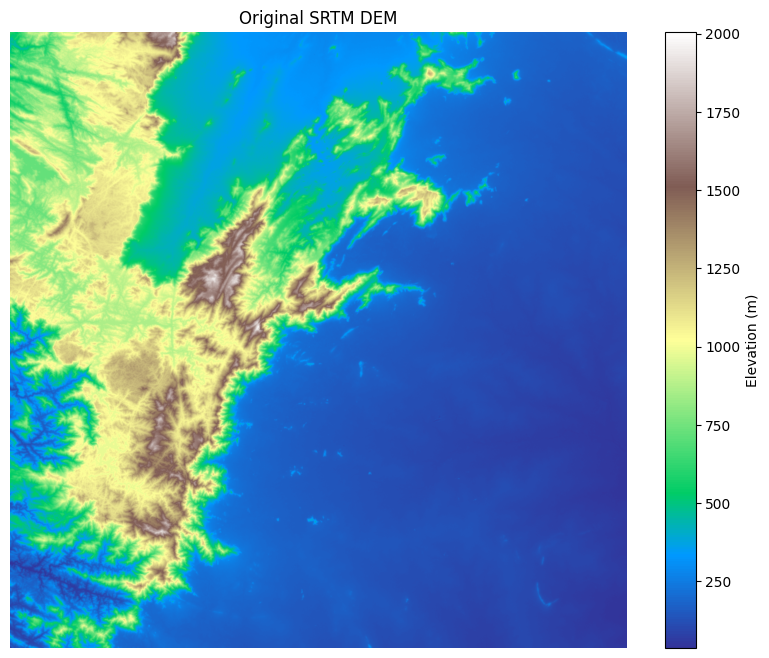

In [38]:
import matplotlib.pyplot as plt

elevation = dem.read(1)

plt.figure(figsize=(10, 8))
plt.imshow(elevation, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Original SRTM DEM")
plt.axis("off")
plt.show()

In [39]:
import geopandas as gpd

districts = gpd.read_file(BOUNDARY_PATH)

print("Total districts:", len(districts))
districts.head()

Total districts: 735


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Ashoknagar,None,76128533B75548370501185,IND,ADM2,"POLYGON ((78.17491 24.84254, 78.17675 24.84188..."
1,Raisen,None,76128533B57893545331548,IND,ADM2,"POLYGON ((77.38167 23.07004, 77.38262 23.07056..."
2,Chhindwara,None,76128533B70646408240587,IND,ADM2,"POLYGON ((79.23988 22.79135, 79.24004 22.79002..."
3,Betul,None,76128533B82559220423608,IND,ADM2,"POLYGON ((78.27229 22.39973, 78.27269 22.39938..."
4,Hoshangabad,None,76128533B45314020251888,IND,ADM2,"POLYGON ((78.03027 22.79953, 78.03227 22.79883..."


In [40]:
districts.columns

Index(['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType',
       'geometry'],
      dtype='object')

In [41]:
# Display all district names alphabetically
district_names = sorted(districts["shapeName"].unique())

for name in district_names:
    print(name)

Adilabad
Agar
Agra
Ahmadabad
Ahmadnagar
Aizawl
Ajmer
Akola
Alappuzha
Aligarh
Alipurduar
Alirajpur
Allahabad
Almora
Alwar
Ambala
Ambedkar Nagar
Amethi
Amravati
Amreli
Amritsar
Anand
Anantapur
Anantnag
Anjaw
Anugul
Anuppur
Araria
Aravali
Ariyalur
Arwal
Ashoknagar
Auraiya
Aurangabad
Azamgarh
Badgam
Bagalkot
Bageshwar
Baghpat
Bahraich
Baksa
Balaghat
Balangir
Baleshwar
Ballia
Balod
Baloda Bazar
Balrampur
Banas Kantha
Banda
Bandipore
Bangalore
Bangalore Rural
Banka
Bankura
Banswara
Bara Banki
Baramula
Baran
Barddhaman
Bareilly
Bargarh
Barmer
Barnala
Barpeta
Barwani
Bastar
Basti
Bathinda
Batod
Baudh
Begusarai
Belgaum
Bellary
Bemetra
Betul
Bhadradri
Bhadrak
Bhagalpur
Bhandara
Bharatpur
Bharuch
Bhavnagar
Bhilwara
Bhind
Bhiwani
Bhojpur
Bhopal
Bid
Bidar
Bijapur
Bijnor
Bikaner
Bilaspur
Birbhum
Bishnupur
Biswanath
Bokaro
Bongaigaon
Budaun
Bulandshahr
Buldana
Bundi
Burhanpur
Buxar
Cachar
Central
Chamarajanagar
Chamba
Chamoli
Champawat
Champhai
Chandauli
Chandel
Chandigarh
Chandrapur
Changlang
Charai

In [42]:
# ======================================================
# Extract Idukki District Boundary
# ======================================================

idukki = districts[districts["shapeName"] == "Idukki"].copy()

print(f"Number of features: {len(idukki)}")

idukki

Number of features: 1


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
363,Idukki,None,76128533B35083559759016,IND,ADM2,"POLYGON ((77.28501 9.27265, 77.28412 9.27302, ..."


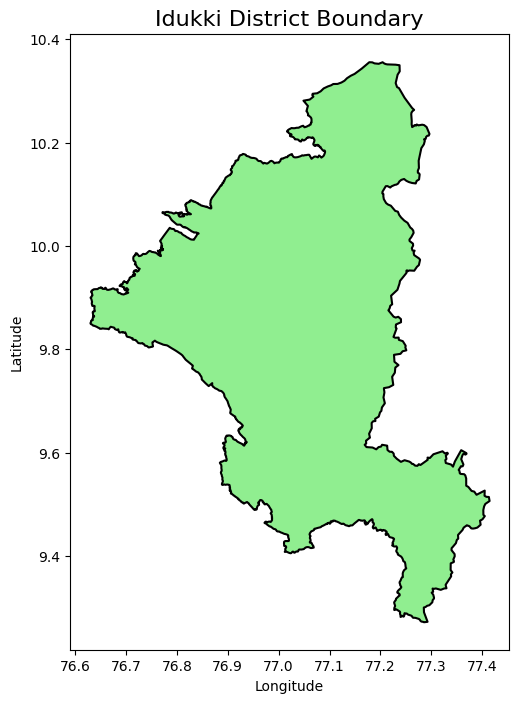

In [43]:
plt.figure(figsize=(8, 8))

idukki.plot(
    ax=plt.gca(),
    facecolor="lightgreen",
    edgecolor="black",
    linewidth=1.5
)

plt.title("Idukki District Boundary", fontsize=16)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [44]:
# ======================================================
# Save Idukki Boundary
# ======================================================

IDUKKI_BOUNDARY = os.path.join(
    OUTPUT_RASTER,
    "idukki_boundary.shp"
)

idukki.to_file(IDUKKI_BOUNDARY)

print("Boundary saved successfully!")

print(IDUKKI_BOUNDARY)

Boundary saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/idukki_boundary.shp


In [45]:
print("DEM CRS:", dem.crs)
print("Boundary CRS:", idukki.crs)

DEM CRS: EPSG:4326
Boundary CRS: EPSG:4326


In [46]:
# ======================================================
# Reproject Boundary if CRS differs
# ======================================================

if idukki.crs != dem.crs:
    idukki = idukki.to_crs(dem.crs)
    print("Boundary reprojected to DEM CRS.")
else:
    print("CRS already matches.")

CRS already matches.


In [47]:
# ======================================================
# Clip DEM to Idukki Boundary
# ======================================================

from rasterio.mask import mask

geometries = idukki.geometry.values

clipped_dem, clipped_transform = mask(
    dem,
    geometries,
    crop=True
)

print("DEM clipped successfully.")

DEM clipped successfully.


In [48]:
# ======================================================
# Update Metadata
# ======================================================

clipped_meta = dem.meta.copy()

clipped_meta.update({

    "driver": "GTiff",

    "height": clipped_dem.shape[1],

    "width": clipped_dem.shape[2],

    "transform": clipped_transform

})

In [49]:
# ======================================================
# Save Clipped DEM
# ======================================================

CLIPPED_DEM = os.path.join(
    OUTPUT_RASTER,
    "clipped_dem.tif"
)

with rasterio.open(
    CLIPPED_DEM,
    "w",
    **clipped_meta
) as dst:

    dst.write(clipped_dem)

print("Clipped DEM saved successfully!")

print(CLIPPED_DEM)

Clipped DEM saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/clipped_dem.tif


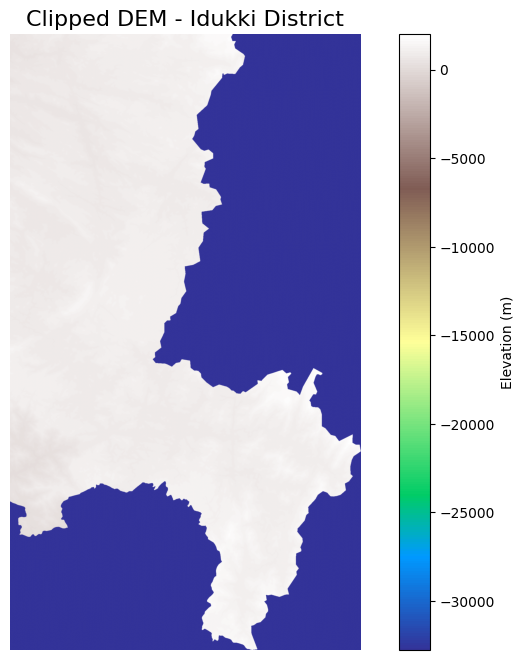

In [50]:
plt.figure(figsize=(10,8))

plt.imshow(
    clipped_dem[0],
    cmap="terrain"
)

plt.colorbar(label="Elevation (m)")

plt.title(
    "Clipped DEM - Idukki District",
    fontsize=16
)

plt.axis("off")

plt.show()

In [51]:
print(idukki)

    shapeName shapeISO                  shapeID shapeGroup shapeType  \
363    Idukki     None  76128533B35083559759016        IND      ADM2   

                                              geometry  
363  POLYGON ((77.28501 9.27265, 77.28412 9.27302, ...  


In [52]:
print("DEM bounds:")
print(dem.bounds)

print("\nIdukki bounds:")
print(idukki.total_bounds)


DEM bounds:
BoundingBox(left=76.99986111111112, bottom=8.999861111111109, right=78.0001388888889, top=10.000138888888888)

Idukki bounds:
[76.62944  9.27265 77.41332 10.35645]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Getting started.pdf', 'Classroom (1)', 'Classroom', 'DocScanner Nov 23, 2021 14.42 (1).pdf', 'IMG_20211123_143535_1.jpg', 'DocScanner Nov 23, 2021 14.39.pdf', 'DocScanner Nov 23, 2021 14.42.pdf', 'ENG Class work.pdf', 'IMG_4048.JPG', 'IMG_4046.JPG', 'IMG_4047.JPG', 'DocScanner Nov 23, 2021 14.43.pdf', 'rough record template.gdoc', 'ENG ASSIGNEMENT 4.pdf', 'yew-oysm-onm – 10 Feb 2022.pdf', 'WEBINAR FEEDBACK FORM - "Future Construction Management: Integrated openBIM Management with BEXEL Manager".gform', 'ASCE webinar.gsheet', 'ENG Assignment No.6 .pdf', 'Test paper ,Bee.pdf', 'ENG ASSIGNMENT 6.pdf', 'ENG Assignment 7.pdf', 'OCEAN ENERGY.pdf', 'OCEAN ENERGY .pdf..pdf', 'TEST PAPER ,MODULE 2,BEE.pdf', 'shemi.pdf', 'shemi 2.pdf', 'Shemi 3.pdf', 'IGBC EVENT FEEDBACK FORM.gform', 'SSD,Dictation,Nazrin Khan P (2).pdf', 'SSD,Dictation,Nazrin Khan P (1).pdf', 'SSD,Dictation,Nazrin Khan P.pdf', 'Document from Khan.pdf', ' DOC .pdf', 'Document from Khan', 'DocScanner Nov 11, 

In [4]:
import os

project = "/content/drive/MyDrive/Landslide-Hazard-Zonation"

print(os.listdir(project))

['data', 'outputs', 'notebooks']


In [5]:
import os

project = "/content/drive/MyDrive/Landslide-Hazard-Zonation"

for root, dirs, files in os.walk(project):
    print(root)

/content/drive/MyDrive/Landslide-Hazard-Zonation
/content/drive/MyDrive/Landslide-Hazard-Zonation/data
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/dem
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/boundary
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/sentinel2
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/geology
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/landslides
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/tables
/content/drive/MyDrive/Landslide-Hazard-Zonation/notebooks


In [6]:
for root, dirs, files in os.walk("/content/drive/MyDrive/Landslide-Hazard-Zonation"):
    print(root)

/content/drive/MyDrive/Landslide-Hazard-Zonation
/content/drive/MyDrive/Landslide-Hazard-Zonation/data
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/dem
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/boundary
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/sentinel2
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/geology
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/landslides
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/tables
/content/drive/MyDrive/Landslide-Hazard-Zonation/notebooks


In [7]:
import os

dem_folder = "/content/drive/MyDrive/Landslide-Hazard-Zonation/data/dem"

print("Files in DEM folder:")
print(os.listdir(dem_folder))

Files in DEM folder:
['n09_e077_1arc_v3.tif', 'n09_e076_1arc_v3.tif', 'n10_e077_1arc_v3.tif', 'n10_e076_1arc_v3.tif']


## 3. Merge SRTM DEM Tiles

The Idukki district spans multiple SRTM tiles. Therefore, all required DEM tiles are merged into a single seamless raster before clipping to the district boundary.

This preprocessing step ensures complete terrain coverage and avoids missing elevation data at the district edges.

In [8]:
# Import required libraries for DEM mosaicking

import os
import glob
import rasterio
from rasterio.merge import merge

In [9]:
# Define the DEM folder path

dem_folder = "/content/drive/MyDrive/Landslide-Hazard-Zonation/data/dem"

# Find all GeoTIFF files
dem_files = sorted(glob.glob(os.path.join(dem_folder, "*.tif")))

print("DEM tiles found:\n")

for file in dem_files:
    print(os.path.basename(file))

DEM tiles found:

n09_e076_1arc_v3.tif
n09_e077_1arc_v3.tif
n10_e076_1arc_v3.tif
n10_e077_1arc_v3.tif


In [10]:
# Open each DEM tile

src_files = []

for file in dem_files:
    src = rasterio.open(file)
    src_files.append(src)

print(f"Successfully opened {len(src_files)} DEM tiles.")

Successfully opened 4 DEM tiles.


In [11]:
# Merge the four DEM tiles into a single raster

mosaic, out_transform = merge(src_files)

print("DEM tiles merged successfully!")
print(f"Merged raster shape: {mosaic.shape}")

DEM tiles merged successfully!
Merged raster shape: (1, 7201, 7201)


In [12]:
# Copy metadata from the first DEM tile

out_meta = src_files[0].meta.copy()

# Update metadata for the merged raster

out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform
})

print("Metadata updated successfully.")

Metadata updated successfully.


In [13]:
# Output file path

merged_dem = os.path.join(dem_folder, "merged_dem.tif")

# Save merged raster

with rasterio.open(merged_dem, "w", **out_meta) as dest:
    dest.write(mosaic)

print("Merged DEM saved successfully!")
print(merged_dem)

Merged DEM saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/dem/merged_dem.tif


In [14]:
# Output file path

merged_dem = os.path.join(dem_folder, "merged_dem.tif")

# Save merged raster

with rasterio.open(merged_dem, "w", **out_meta) as dest:
    dest.write(mosaic)

print("Merged DEM saved successfully!")
print(merged_dem)

Merged DEM saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/data/dem/merged_dem.tif


In [15]:
# Close all opened DEM files

for src in src_files:
    src.close()

print("All DEM files closed.")

All DEM files closed.


In [16]:
# Open the merged DEM and display its properties

with rasterio.open(merged_dem) as src:
    print("Merged DEM Information")
    print("----------------------")
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)

Merged DEM Information
----------------------
CRS: EPSG:4326
Width: 7201
Height: 7201
Bounds: BoundingBox(left=75.99986111111112, bottom=8.999861111111109, right=78.0001388888889, top=11.000138888888888)


## 4. Clip the DEM to the Idukki District Boundary

The merged SRTM DEM covers a much larger area than the study region. To reduce processing time and ensure all subsequent analyses focus only on the study area, the DEM is clipped using the Idukki district administrative boundary.

The clipped DEM serves as the base dataset for elevation, hillshade, slope, aspect, and drainage analyses.

In [18]:
from rasterio.mask import mask
import rasterio
import geopandas as gpd
import json

In [19]:
# Load the district boundary shapefile

boundary_file = "/content/drive/MyDrive/Landslide-Hazard-Zonation/data/boundary/geoBoundaries-IND-ADM2.shp"

districts = gpd.read_file(boundary_file)

# Select Idukki district
idukki = districts[districts["shapeName"] == "Idukki"]

print(idukki[["shapeName"]])

    shapeName
363    Idukki


In [20]:
# Clip the merged DEM using the Idukki boundary

from rasterio.mask import mask

with rasterio.open(merged_dem) as src:

    clipped_image, clipped_transform = mask(
        src,
        idukki.geometry,
        crop=True
    )

    clipped_meta = src.meta.copy()

print("DEM clipped successfully!")

DEM clipped successfully!


In [21]:
# Update metadata for the clipped DEM

clipped_meta.update({
    "driver": "GTiff",
    "height": clipped_image.shape[1],
    "width": clipped_image.shape[2],
    "transform": clipped_transform
})

print("Metadata updated.")

Metadata updated.


In [22]:
# Save the clipped DEM

clipped_dem = "/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/idukki_dem.tif"

with rasterio.open(clipped_dem, "w", **clipped_meta) as dst:
    dst.write(clipped_image)

print("Clipped DEM saved successfully!")
print(clipped_dem)

Clipped DEM saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/idukki_dem.tif


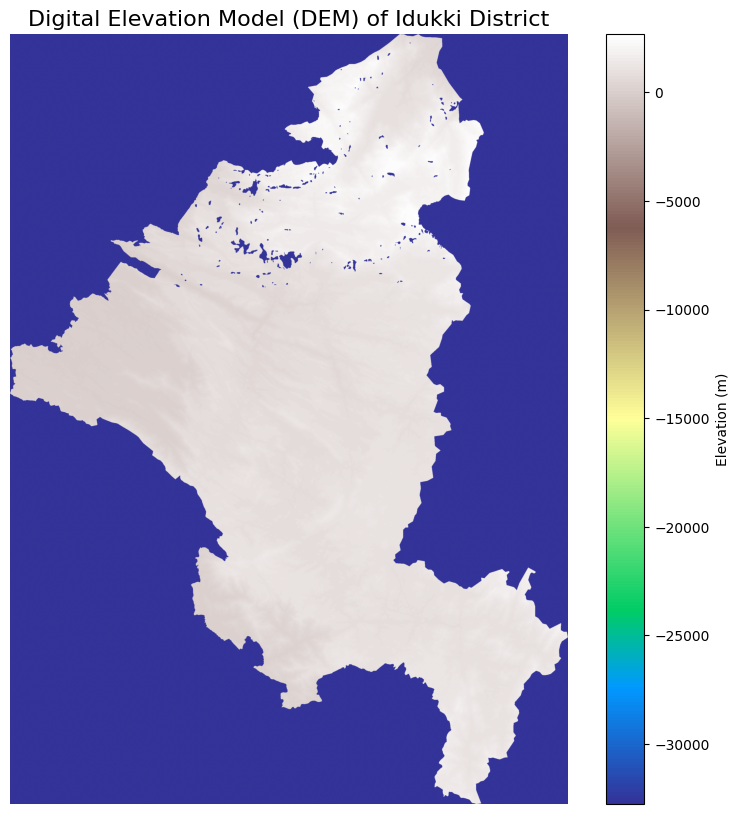

In [23]:
import matplotlib.pyplot as plt

with rasterio.open(clipped_dem) as src:
    dem = src.read(1)

plt.figure(figsize=(10, 10))

plt.imshow(dem, cmap="terrain")

plt.title("Digital Elevation Model (DEM) of Idukki District", fontsize=16)

plt.colorbar(label="Elevation (m)")

plt.axis("off")

plt.show()

In [24]:
import numpy as np

valid_dem = dem[dem != src.nodata]

print("Elevation Statistics")
print("--------------------")
print(f"Minimum Elevation : {valid_dem.min():.2f} m")
print(f"Maximum Elevation : {valid_dem.max():.2f} m")
print(f"Mean Elevation    : {valid_dem.mean():.2f} m")

Elevation Statistics
--------------------
Minimum Elevation : 13.00 m
Maximum Elevation : 2685.00 m
Mean Elevation    : 973.47 m


## 5. Generate Hillshade

A hillshade is a shaded relief representation of the terrain that enhances the visualization of topographic features by simulating illumination from the northwest.

Hillshade improves the interpretation of ridges, valleys, escarpments, and steep slopes, providing a more realistic representation of the landscape.

In [25]:
import numpy as np
from matplotlib.colors import LightSource

In [26]:
with rasterio.open(clipped_dem) as src:
    dem = src.read(1)
    profile = src.profile

In [27]:
# Create hillshade

ls = LightSource(azdeg=315, altdeg=45)

hillshade = ls.hillshade(
    dem,
    vert_exag=1,
    dx=1,
    dy=1
)

print("Hillshade generated successfully.")

Hillshade generated successfully.


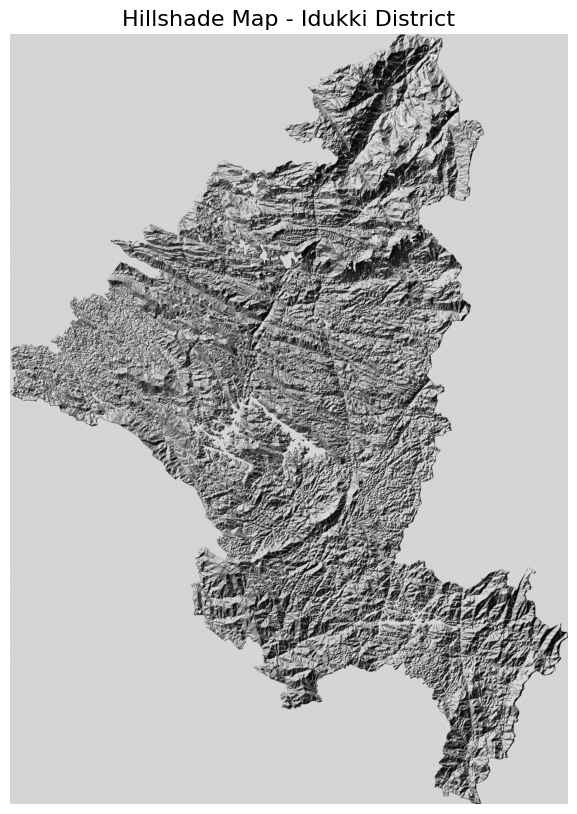

In [28]:
plt.figure(figsize=(10,10))

plt.imshow(hillshade, cmap="gray")

plt.title("Hillshade Map - Idukki District", fontsize=16)

plt.axis("off")

plt.show()

In [29]:
plt.figure(figsize=(10,10))

plt.imshow(hillshade, cmap="gray")

plt.axis("off")

hillshade_path = "/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures/idukki_hillshade.png"

plt.savefig(
    hillshade_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Hillshade saved successfully!")
print(hillshade_path)

Hillshade saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures/idukki_hillshade.png


## 6. Publication-Quality Digital Elevation Model (DEM)

This section generates a high-resolution elevation map of Idukki district using the clipped SRTM DEM. The figure is formatted for reports, publications, and portfolio presentation with appropriate labels and a terrain colour scale.

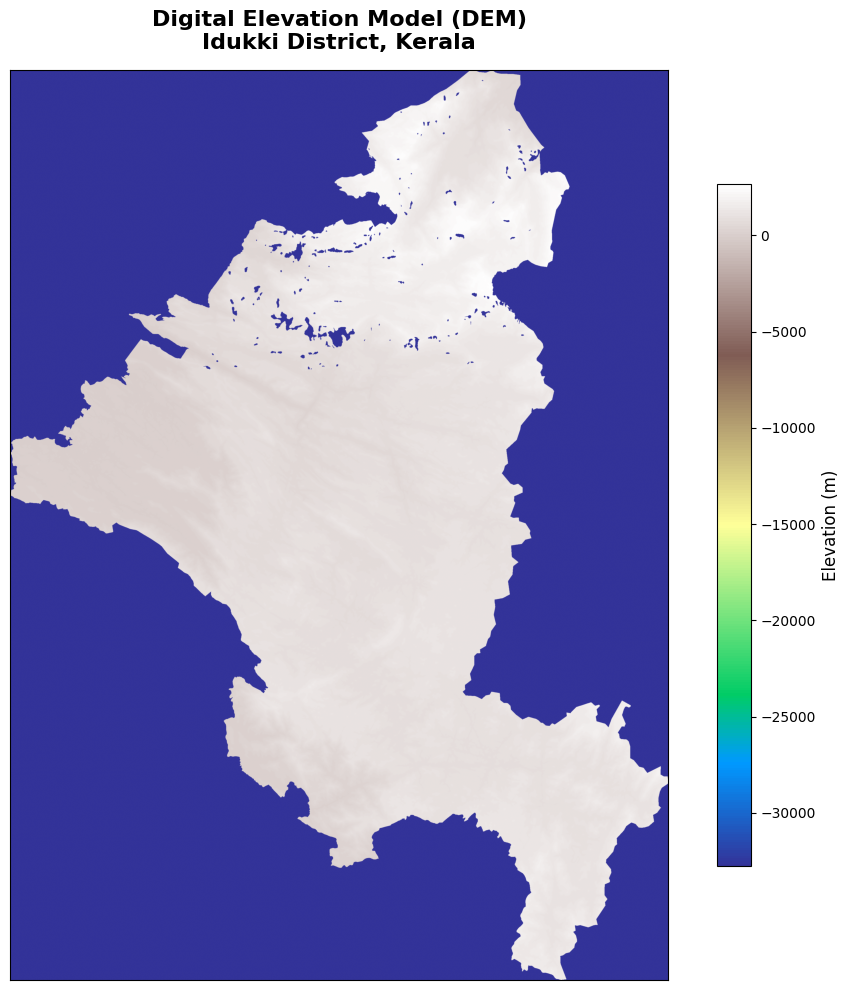

In [30]:
import matplotlib.pyplot as plt
import rasterio

# Read the clipped DEM
with rasterio.open(clipped_dem) as src:
    dem = src.read(1)

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Display DEM
img = ax.imshow(
    dem,
    cmap="terrain",
    vmin=dem.min(),
    vmax=dem.max()
)

# Title
ax.set_title(
    "Digital Elevation Model (DEM)\nIdukki District, Kerala",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Remove axis
ax.set_xticks([])
ax.set_yticks([])

# Add colorbar
cbar = plt.colorbar(
    img,
    ax=ax,
    shrink=0.75
)

cbar.set_label(
    "Elevation (m)",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [31]:
output_figure = "/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures/idukki_dem_map.png"

fig.savefig(
    output_figure,
    dpi=300,
    bbox_inches="tight"
)

print("Publication-quality DEM saved successfully!")
print(output_figure)

Publication-quality DEM saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/figures/idukki_dem_map.png


In [32]:
print("=" * 60)
print("NOTEBOOK 1 COMPLETED")
print("=" * 60)

print("\nOutputs generated:")
print("✓ merged_dem.tif")
print("✓ idukki_dem.tif")
print("✓ idukki_hillshade.png")
print("✓ idukki_dem_map.png")

print("\nNotebook 1 processing complete.")

NOTEBOOK 1 COMPLETED

Outputs generated:
✓ merged_dem.tif
✓ idukki_dem.tif
✓ idukki_hillshade.png
✓ idukki_dem_map.png

Notebook 1 processing complete.
